In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path = '/content/heating_dataset.csv'
df = pd.read_csv(path)

Mounted at /content/drive


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
df.dropna(inplace=True)
label_encoders={}
for col in df.select_dtypes(include=['object']).columns:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  label_encoders[col]=le

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['target']).values
y=df['target'].values
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
svm_linear=SVC(kernel='poly',C=1)
svm_linear.fit(x_train,y_train)
y_pred_linear=svm_linear.predict(x_test)

In [ ]:
#acuracy score
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred_linear)
cm=confusion_matrix(y_test,y_pred_linear)
cm


array([[ 85,  17],
       [  2, 101]])

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

path1='/content/train_u6lujuX_CVtuZ9i.csv'
df = pd.read_csv(path1)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.isna().sum()

,0
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50
Property_Area,0


In [ ]:
import pandas as pd

# assuming your dataframe name is df

# CATEGORICAL COLUMNS
categorical_cols = [
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# NUMERICAL COLUMNS
numerical_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# check remaining missing values
print(df.isnull().sum())



Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipython-input-1872345170.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-1872345170.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df.isnull().sum()

,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = [
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
df.head(10)

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1
6,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1
7,1,3,0,0,3036,2504.0,158.0,360.0,0.0,1,0
8,1,2,0,0,4006,1526.0,168.0,360.0,1.0,2,1
9,1,1,0,0,12841,10968.0,349.0,360.0,1.0,1,0


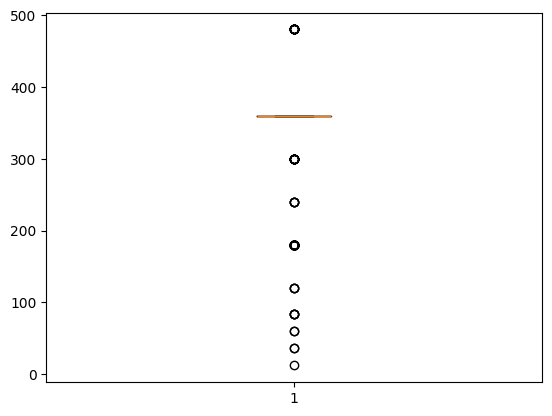

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.boxplot(df['Loan_Amount_Term'])
plt.show()

In [ ]:
numerical_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()


In [ ]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df[col] = df[col].clip(lower_bound, upper_bound)


In [ ]:
for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col} (After Outlier Handling)')
    plt.ylabel(col)
    plt.show()


In [ ]:
x=df.drop(columns=['Loan_Status']).values
y=df['Loan_Status'].values

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Re-split and scale the data for the current dataset
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_new)
x_test_scaled = scaler.transform(x_test_new)

# Train and predict with SVC using the newly prepared data
svm_linear = SVC(kernel='poly', C=1)
svm_linear.fit(x_train_scaled, y_train_new)
y_pred_linear = svm_linear.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(y_test_new, y_pred_linear)
cm

array([[ 85,  17],
       [  2, 101]])

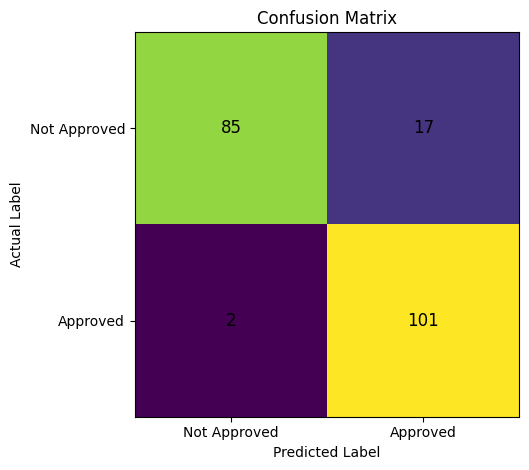

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Removed st.subheader("📊 Confusion Matrix (Heatmap)") as 'st' is not defined

fig, ax = plt.subplots()

im = ax.imshow(cm)

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", fontsize=12)

# Labels
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix")

# Tick labels
ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(["Not Approved", "Approved"])
ax.set_yticklabels(["Not Approved", "Approved"])

plt.tight_layout()
plt.show() # Replaced st.pyplot(fig) with plt.show()